In [1]:
# ================================================================
# MediScan — Day 14
# Cell 1: Environment + Previous Artifacts Restore
# ================================================================

from google.colab import drive
from pathlib import Path
import shutil
import os
import torch

print("=" * 65)
print("MediScan — Day 14: Edge Case & Failure Analysis")
print("=" * 65)

# ------------------------------------------------
# Mount Google Drive
# ------------------------------------------------
drive.mount("/content/drive", force_remount=False)

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
PROJECT = Path("/content/MediScan")

print("\nDrive project:", DRIVE_PROJECT)
print("Local project:", PROJECT)

# ------------------------------------------------
# Create local directories
# ------------------------------------------------
for folder in [
    "data/raw",
    "data/processed",
    "figures",
    "reports",
    "models",
    "app"
]:
    (PROJECT / folder).mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# Restore important project folders from Drive
# ------------------------------------------------

folders_to_restore = [
    "data/raw",
    "data/processed",
    "figures",
    "reports",
    "models",
    "app"
]

for folder in folders_to_restore:
    src = DRIVE_PROJECT / folder
    dst = PROJECT / folder

    if src.exists():
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✓ Restored: {folder}")
    else:
        print(f"⚠ Not found on Drive: {folder}")

# ------------------------------------------------
# Environment verification
# ------------------------------------------------

print("\nEnvironment:")
print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Device: CPU")

# ------------------------------------------------
# Important artifact verification
# ------------------------------------------------

required_files = [
    PROJECT / "models/efficientnet_b0_best_day8.pth",
    PROJECT / "reports/day9_classification_report.csv",
    PROJECT / "reports/day9_evaluation_metrics.json",
    PROJECT / "reports/day9_roc_auc.csv",
    PROJECT / "reports/day11_efficientnet_y_true.npy",
    PROJECT / "reports/day11_efficientnet_y_pred.npy",
]

print("\nRequired Day 14 artifacts:")

for file_path in required_files:
    print(
        f"✓ {file_path.relative_to(PROJECT)}"
        if file_path.exists()
        else
        f"⚠ Missing: {file_path.relative_to(PROJECT)}"
    )

print("\n" + "=" * 65)
print("✓ Day 14 environment ready")
print("=" * 65)

MediScan — Day 14: Edge Case & Failure Analysis
Mounted at /content/drive

Drive project: /content/drive/MyDrive/MediScan
Local project: /content/MediScan
✓ Restored: data/raw
✓ Restored: data/processed
✓ Restored: figures
✓ Restored: reports
✓ Restored: models
✓ Restored: app

Environment:
PyTorch version: 2.11.0+cu128
CUDA available : True
GPU: Tesla T4

Required Day 14 artifacts:
✓ models/efficientnet_b0_best_day8.pth
✓ reports/day9_classification_report.csv
✓ reports/day9_evaluation_metrics.json
✓ reports/day9_roc_auc.csv
✓ reports/day11_efficientnet_y_true.npy
✓ reports/day11_efficientnet_y_pred.npy

✓ Day 14 environment ready


In [2]:
# ================================================================
# MediScan — Day 14
# Cell 2: Identify Misclassified Test Samples
# ================================================================

import numpy as np
import pandas as pd
from pathlib import Path

PROJECT = Path("/content/MediScan")
REPORTS = PROJECT / "reports"

# ------------------------------------------------
# Load Day 9 / Day 11 EfficientNet predictions
# ------------------------------------------------

y_true = np.load(REPORTS / "day11_efficientnet_y_true.npy")
y_pred = np.load(REPORTS / "day11_efficientnet_y_pred.npy")

print("=" * 65)
print("MediScan — Misclassified Sample Analysis")
print("=" * 65)

print("\nPrediction arrays:")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

# ------------------------------------------------
# Load test CSV
# ------------------------------------------------

test_df = pd.read_csv(PROJECT / "data/processed/test.csv")

print("\nTest CSV:")
print("Samples:", len(test_df))
print("Columns:", list(test_df.columns))

# ------------------------------------------------
# Class mapping
# ------------------------------------------------

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

idx_to_class = {
    i: name for i, name in enumerate(class_names)
}

# ------------------------------------------------
# Find misclassified samples
# ------------------------------------------------

misclassified_mask = y_true != y_pred

misclassified_indices = np.where(misclassified_mask)[0]

print("\nTotal test samples:", len(y_true))
print("Correct predictions:", np.sum(~misclassified_mask))
print("Misclassified:", len(misclassified_indices))

accuracy = np.mean(y_true == y_pred)

print(f"Test accuracy: {accuracy * 100:.2f}%")
print(f"Error rate: {(1 - accuracy) * 100:.2f}%")

# ------------------------------------------------
# Build misclassification dataframe
# ------------------------------------------------

rows = []

for idx in misclassified_indices:

    row = test_df.iloc[idx]

    true_idx = int(y_true[idx])
    pred_idx = int(y_pred[idx])

    rows.append({
        "index": int(idx),
        "image_path": row["image_path"],
        "true_label": idx_to_class[true_idx],
        "predicted_label": idx_to_class[pred_idx],
        "true_index": true_idx,
        "predicted_index": pred_idx
    })

misclassified_df = pd.DataFrame(rows)

# ------------------------------------------------
# Display results
# ------------------------------------------------

print("\nMisclassified samples:")
display(misclassified_df.head(20))

print("\nMisclassification count:",
      len(misclassified_df))

print("\nError pairs:")

if len(misclassified_df) > 0:
    error_pairs = (
        misclassified_df
        .groupby(["true_label", "predicted_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    display(error_pairs)

print("=" * 65)
print("✓ Misclassified samples identified")
print("=" * 65)

MediScan — Misclassified Sample Analysis

Prediction arrays:
y_true shape: (1080,)
y_pred shape: (1080,)

Test CSV:
Samples: 1080
Columns: ['image_path', 'label', 'source']

Total test samples: 1080
Correct predictions: 985
Misclassified: 95
Test accuracy: 91.20%
Error rate: 8.80%

Misclassified samples:


,index,image_path,true_label,predicted_label,true_index,predicted_index
0,6,/content/MediScan/Training/glioma/Tr-gl_1366.jpg,glioma,notumor,0,2
1,13,/content/MediScan/Training/pituitary/Tr-pi_384...,pituitary,notumor,3,2
2,17,/content/MediScan/Training/glioma/Tr-gl_164.jpg,glioma,meningioma,0,1
3,20,/content/MediScan/Training/meningioma/Tr-me_71...,meningioma,pituitary,1,3
4,32,/content/MediScan/Testing/glioma/Te-gl_295.jpg,glioma,notumor,0,2
5,36,/content/MediScan/Training/glioma/Tr-gl_216.jpg,glioma,meningioma,0,1
6,40,/content/MediScan/Testing/glioma/Te-gl_158.jpg,glioma,meningioma,0,1
7,60,/content/MediScan/Training/meningioma/Tr-aug-m...,meningioma,glioma,1,0
8,67,/content/MediScan/Training/glioma/Tr-gl_1027.jpg,glioma,meningioma,0,1
9,71,/content/MediScan/Training/glioma/Tr-gl_206.jpg,glioma,meningioma,0,1



Misclassification count: 95

Error pairs:


,true_label,predicted_label,count
0,glioma,meningioma,33
5,meningioma,pituitary,15
3,meningioma,glioma,13
1,glioma,notumor,8
8,pituitary,meningioma,8
4,meningioma,notumor,7
9,pituitary,notumor,5
6,notumor,meningioma,3
2,glioma,pituitary,2
7,notumor,pituitary,1


✓ Misclassified samples identified


In [3]:
# ================================================================
# MediScan — Day 14
# Cell 3: Save Misclassification Analysis
# ================================================================

from pathlib import Path
import json

PROJECT = Path("/content/MediScan")
REPORTS = PROJECT / "reports"

REPORTS.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# Save all misclassified samples
# ------------------------------------------------

misclassified_path = REPORTS / "day14_misclassified_samples.csv"

misclassified_df.to_csv(
    misclassified_path,
    index=False
)

# ------------------------------------------------
# Error-pair analysis
# ------------------------------------------------

error_pairs = (
    misclassified_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs_path = REPORTS / "day14_error_pairs.csv"

error_pairs.to_csv(
    error_pairs_path,
    index=False
)

# ------------------------------------------------
# Summary
# ------------------------------------------------

summary = {
    "total_test_samples": int(len(y_true)),
    "correct_predictions": int(np.sum(y_true == y_pred)),
    "misclassified_samples": int(len(misclassified_df)),
    "test_accuracy": float(np.mean(y_true == y_pred)),
    "error_rate": float(1 - np.mean(y_true == y_pred)),
    "major_failure_modes": [
        {
            "true_class": str(row["true_label"]),
            "predicted_class": str(row["predicted_label"]),
            "count": int(row["count"])
        }
        for _, row in error_pairs.iterrows()
    ]
}

summary_path = REPORTS / "day14_misclassification_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

# ------------------------------------------------
# Verification
# ------------------------------------------------

print("=" * 65)
print("MediScan — Day 14 Misclassification Reports")
print("=" * 65)

print("\nSaved files:")

for path in [
    misclassified_path,
    error_pairs_path,
    summary_path
]:
    print(f"✓ {path}")

print("\nTop failure modes:")
display(error_pairs)

print("\nOverall:")
print(f"Test Accuracy : {summary['test_accuracy'] * 100:.2f}%")
print(f"Errors        : {summary['misclassified_samples']}")
print(f"Error Rate    : {summary['error_rate'] * 100:.2f}%")

print("\n" + "=" * 65)
print("✓ Misclassification analysis saved successfully")
print("=" * 65)

MediScan — Day 14 Misclassification Reports

Saved files:
✓ /content/MediScan/reports/day14_misclassified_samples.csv
✓ /content/MediScan/reports/day14_error_pairs.csv
✓ /content/MediScan/reports/day14_misclassification_summary.json

Top failure modes:


,true_label,predicted_label,count
0,glioma,meningioma,33
5,meningioma,pituitary,15
3,meningioma,glioma,13
1,glioma,notumor,8
8,pituitary,meningioma,8
4,meningioma,notumor,7
9,pituitary,notumor,5
6,notumor,meningioma,3
2,glioma,pituitary,2
7,notumor,pituitary,1



Overall:
Test Accuracy : 91.20%
Errors        : 95
Error Rate    : 8.80%

✓ Misclassification analysis saved successfully


MediScan — Visual Inspection of Misclassified MRI Samples

Selected samples for visual inspection: 10


,index,true_label,predicted_label,image_path
0,17,glioma,meningioma,/content/MediScan/Training/glioma/Tr-gl_164.jpg
1,36,glioma,meningioma,/content/MediScan/Training/glioma/Tr-gl_216.jpg
2,20,meningioma,pituitary,/content/MediScan/Training/meningioma/Tr-me_71...
3,98,meningioma,pituitary,/content/MediScan/Training/meningioma/Tr-me_47...
4,60,meningioma,glioma,/content/MediScan/Training/meningioma/Tr-aug-m...
5,94,meningioma,glioma,/content/MediScan/Training/meningioma/Tr-me_25...
6,6,glioma,notumor,/content/MediScan/Training/glioma/Tr-gl_1366.jpg
7,32,glioma,notumor,/content/MediScan/Testing/glioma/Te-gl_295.jpg
8,285,pituitary,meningioma,/content/MediScan/Training/pituitary/Tr-pi_416...
9,549,pituitary,meningioma,/content/MediScan/Training/pituitary/Tr-pi_370...


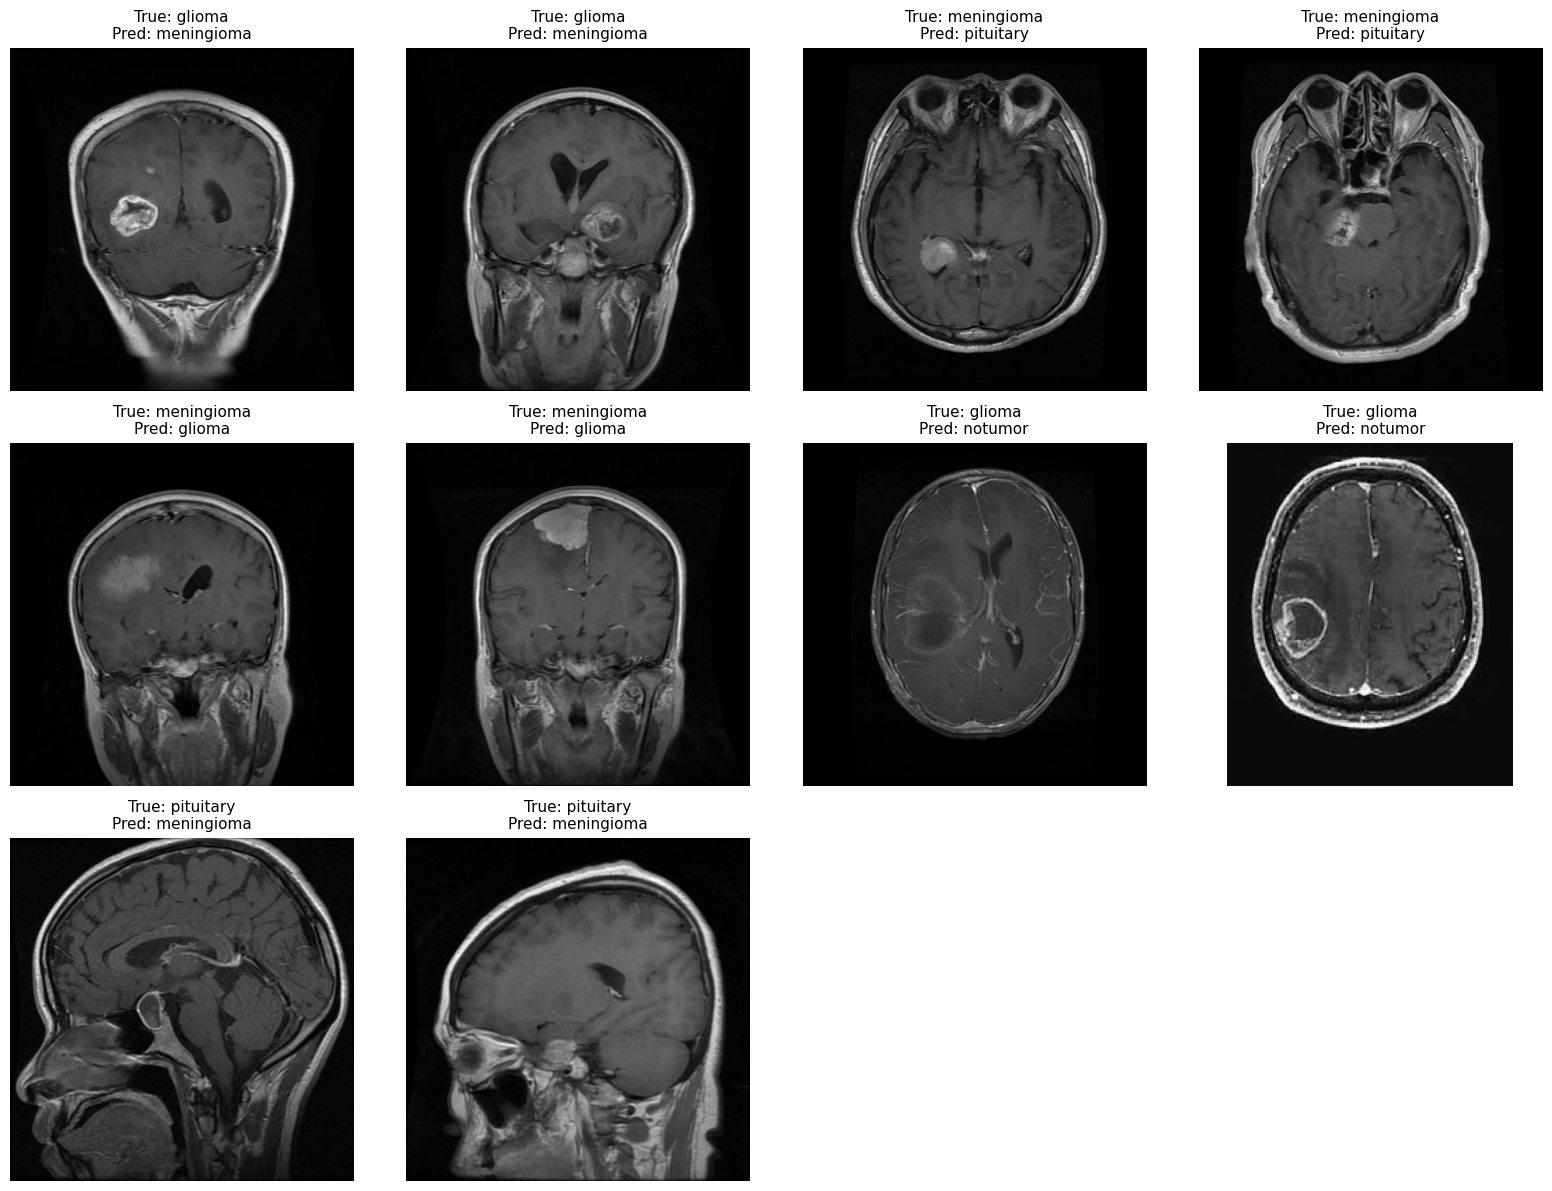


✓ Visualization saved:
/content/MediScan/figures/day14_misclassified_samples_visualization.png
✓ Visual inspection figure generated


In [4]:
# ================================================================
# MediScan — Day 14
# Cell 4: Visual Inspection of Misclassified Samples
# ================================================================

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from pathlib import Path

print("=" * 65)
print("MediScan — Visual Inspection of Misclassified MRI Samples")
print("=" * 65)

# ------------------------------------------------
# Select samples from major failure modes
# ------------------------------------------------

selected_samples = []

# Take up to 2 samples from each major error pair
for _, pair in error_pairs.head(5).iterrows():

    true_class = pair["true_label"]
    predicted_class = pair["predicted_label"]

    pair_samples = misclassified_df[
        (misclassified_df["true_label"] == true_class) &
        (misclassified_df["predicted_label"] == predicted_class)
    ].head(2)

    for _, sample in pair_samples.iterrows():
        selected_samples.append(sample)

# Remove duplicates
selected_df = pd.DataFrame(selected_samples).drop_duplicates(
    subset=["index"]
).reset_index(drop=True)

print(f"\nSelected samples for visual inspection: {len(selected_df)}")

display(
    selected_df[
        ["index", "true_label", "predicted_label", "image_path"]
    ]
)

# ------------------------------------------------
# Display images
# ------------------------------------------------

n = len(selected_df)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(16, rows * 4))

for i, (_, sample) in enumerate(selected_df.iterrows()):

    image_path = Path(sample["image_path"])

    # Handle paths if they point to old locations
    if not image_path.exists():
        filename = image_path.name

        matches = list(
            (PROJECT / "data/raw").rglob(filename)
        )

        if matches:
            image_path = matches[0]

    try:
        image = Image.open(image_path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"True: {sample['true_label']}\n"
            f"Pred: {sample['predicted_label']}",
            fontsize=11
        )

    except Exception as e:
        print(f"⚠ Could not load {image_path.name}: {e}")

plt.tight_layout()

# ------------------------------------------------
# Save figure
# ------------------------------------------------

FIGURES = PROJECT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

visual_path = FIGURES / "day14_misclassified_samples_visualization.png"

plt.savefig(
    visual_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Visualization saved:")
print(visual_path)

print("=" * 65)
print("✓ Visual inspection figure generated")
print("=" * 65)

In [5]:
# ================================================================
# MediScan — Day 14
# Cell 5: Failure Mode & Class-wise Error Analysis
# ================================================================

import pandas as pd
import numpy as np
import json

print("=" * 65)
print("MediScan — Failure Mode Analysis")
print("=" * 65)

# ------------------------------------------------
# Class-wise total / correct / incorrect
# ------------------------------------------------

class_analysis = []

for class_idx, class_name in enumerate(class_names):

    total = int(np.sum(y_true == class_idx))
    correct = int(np.sum((y_true == class_idx) & (y_pred == class_idx)))
    incorrect = total - correct

    error_rate = incorrect / total if total > 0 else 0

    class_analysis.append({
        "class": class_name,
        "total_samples": total,
        "correct_predictions": correct,
        "misclassified_samples": incorrect,
        "accuracy": correct / total if total > 0 else 0,
        "error_rate": error_rate
    })

class_error_df = pd.DataFrame(class_analysis)

print("\nClass-wise Error Analysis:")
display(class_error_df)

# ------------------------------------------------
# Identify highest-error class
# ------------------------------------------------

highest_error_row = class_error_df.loc[
    class_error_df["error_rate"].idxmax()
]

print("\nHighest Error Rate:")
print(
    f"✓ {highest_error_row['class']} "
    f"→ {highest_error_row['error_rate'] * 100:.2f}%"
)

# ------------------------------------------------
# Error direction analysis
# ------------------------------------------------

print("\nFailure Mode Ranking:")

error_pairs_ranked = error_pairs.copy()

error_pairs_ranked["percentage_of_all_errors"] = (
    error_pairs_ranked["count"] / len(misclassified_df) * 100
)

display(error_pairs_ranked)

# ------------------------------------------------
# Save class-wise analysis
# ------------------------------------------------

class_error_path = REPORTS / "day14_class_wise_error_analysis.csv"

class_error_df.to_csv(
    class_error_path,
    index=False
)

# ------------------------------------------------
# Save failure mode analysis
# ------------------------------------------------

failure_mode_path = REPORTS / "day14_failure_modes.csv"

error_pairs_ranked.to_csv(
    failure_mode_path,
    index=False
)

# ------------------------------------------------
# Summary
# ------------------------------------------------

failure_summary = {
    "total_test_samples": int(len(y_true)),
    "correct_predictions": int(np.sum(y_true == y_pred)),
    "misclassified_samples": int(len(misclassified_df)),
    "accuracy": float(np.mean(y_true == y_pred)),
    "error_rate": float(1 - np.mean(y_true == y_pred)),
    "highest_error_class": str(highest_error_row["class"]),
    "highest_error_rate": float(highest_error_row["error_rate"]),
    "top_failure_modes": [
        {
            "true_class": str(row["true_label"]),
            "predicted_class": str(row["predicted_label"]),
            "count": int(row["count"]),
            "percentage_of_errors": float(
                row["percentage_of_all_errors"]
            )
        }
        for _, row in error_pairs_ranked.head(5).iterrows()
    ]
}

failure_summary_path = (
    REPORTS / "day14_failure_mode_summary.json"
)

with open(failure_summary_path, "w") as f:
    json.dump(failure_summary, f, indent=4)

# ------------------------------------------------
# Final output
# ------------------------------------------------

print("\nSaved:")
print(f"✓ {class_error_path}")
print(f"✓ {failure_mode_path}")
print(f"✓ {failure_summary_path}")

print("\n" + "=" * 65)
print("✓ Failure mode analysis completed")
print("=" * 65)

MediScan — Failure Mode Analysis

Class-wise Error Analysis:


,class,total_samples,correct_predictions,misclassified_samples,accuracy,error_rate
0,glioma,270,227,43,0.840741,0.159259
1,meningioma,270,235,35,0.870370,0.129630
2,notumor,270,266,4,0.985185,0.014815
3,pituitary,270,257,13,0.951852,0.048148



Highest Error Rate:
✓ glioma → 15.93%

Failure Mode Ranking:


,true_label,predicted_label,count,percentage_of_all_errors
0,glioma,meningioma,33,34.736842
5,meningioma,pituitary,15,15.789474
3,meningioma,glioma,13,13.684211
1,glioma,notumor,8,8.421053
8,pituitary,meningioma,8,8.421053
4,meningioma,notumor,7,7.368421
9,pituitary,notumor,5,5.263158
6,notumor,meningioma,3,3.157895
2,glioma,pituitary,2,2.105263
7,notumor,pituitary,1,1.052632



Saved:
✓ /content/MediScan/reports/day14_class_wise_error_analysis.csv
✓ /content/MediScan/reports/day14_failure_modes.csv
✓ /content/MediScan/reports/day14_failure_mode_summary.json

✓ Failure mode analysis completed


In [6]:
# ================================================================
# MediScan — Day 14
# Cell 6: Class Balance & Bias Analysis
# ================================================================

print("=" * 65)
print("MediScan — Class Balance & Bias Analysis")
print("=" * 65)

# ------------------------------------------------
# Actual class distribution in test set
# ------------------------------------------------

true_distribution = (
    pd.Series(y_true)
    .map(idx_to_class)
    .value_counts()
    .reindex(class_names, fill_value=0)
)

# ------------------------------------------------
# Predicted class distribution
# ------------------------------------------------

pred_distribution = (
    pd.Series(y_pred)
    .map(idx_to_class)
    .value_counts()
    .reindex(class_names, fill_value=0)
)

# ------------------------------------------------
# Build comparison table
# ------------------------------------------------

bias_df = pd.DataFrame({
    "class": class_names,
    "actual_samples": true_distribution.values,
    "predicted_samples": pred_distribution.values
})

bias_df["actual_percentage"] = (
    bias_df["actual_samples"] / len(y_true) * 100
)

bias_df["predicted_percentage"] = (
    bias_df["predicted_samples"] / len(y_pred) * 100
)

bias_df["distribution_difference"] = (
    bias_df["predicted_percentage"]
    - bias_df["actual_percentage"]
)

# Add class error rate
bias_df = bias_df.merge(
    class_error_df[
        ["class", "accuracy", "error_rate"]
    ],
    on="class",
    how="left"
)

# ------------------------------------------------
# Display
# ------------------------------------------------

print("\nClass Distribution & Performance:")
display(bias_df)

# ------------------------------------------------
# Check dataset balance
# ------------------------------------------------

counts = bias_df["actual_samples"]

is_balanced = counts.nunique() == 1

print("\nDataset Balance:")
if is_balanced:
    print("✓ Test set is class-balanced")
else:
    print("⚠ Test set is not perfectly class-balanced")

# ------------------------------------------------
# Prediction distribution shift
# ------------------------------------------------

print("\nPrediction Distribution Shift:")

for _, row in bias_df.iterrows():

    difference = row["distribution_difference"]

    if abs(difference) < 2:
        status = "Low shift"
    elif abs(difference) < 5:
        status = "Moderate shift"
    else:
        status = "High shift"

    print(
        f"✓ {row['class']}: "
        f"{difference:+.2f} percentage points — {status}"
    )

# ------------------------------------------------
# Identify most over/under predicted classes
# ------------------------------------------------

most_over = bias_df.loc[
    bias_df["distribution_difference"].idxmax()
]

most_under = bias_df.loc[
    bias_df["distribution_difference"].idxmin()
]

print("\nLargest Prediction Distribution Differences:")

print(
    f"Most over-predicted : {most_over['class']} "
    f"({most_over['distribution_difference']:+.2f} pp)"
)

print(
    f"Most under-predicted: {most_under['class']} "
    f"({most_under['distribution_difference']:+.2f} pp)"
)

# ------------------------------------------------
# Save bias analysis
# ------------------------------------------------

bias_path = REPORTS / "day14_bias_analysis.csv"

bias_df.to_csv(
    bias_path,
    index=False
)

print("\nSaved:")
print(f"✓ {bias_path}")

print("\n" + "=" * 65)
print("✓ Bias analysis completed")
print("=" * 65)

MediScan — Class Balance & Bias Analysis

Class Distribution & Performance:


,class,actual_samples,predicted_samples,actual_percentage,predicted_percentage,distribution_difference,accuracy,error_rate
0,glioma,270,240,25.0,22.222222,-2.777778,0.840741,0.159259
1,meningioma,270,279,25.0,25.833333,0.833333,0.870370,0.129630
2,notumor,270,286,25.0,26.481481,1.481481,0.985185,0.014815
3,pituitary,270,275,25.0,25.462963,0.462963,0.951852,0.048148



Dataset Balance:
✓ Test set is class-balanced

Prediction Distribution Shift:
✓ glioma: -2.78 percentage points — Moderate shift
✓ meningioma: +0.83 percentage points — Low shift
✓ notumor: +1.48 percentage points — Low shift
✓ pituitary: +0.46 percentage points — Low shift

Largest Prediction Distribution Differences:
Most over-predicted : notumor (+1.48 pp)
Most under-predicted: glioma (-2.78 pp)

Saved:
✓ /content/MediScan/reports/day14_bias_analysis.csv

✓ Bias analysis completed


In [7]:
# ================================================================
# MediScan — Day 14
# Cell 7: Final Error & Edge Case Analysis Report
# ================================================================

from pathlib import Path
import json
from datetime import datetime

PROJECT = Path("/content/MediScan")
REPORTS = PROJECT / "reports"

REPORTS.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# Main findings
# ------------------------------------------------

top_failure = error_pairs_ranked.iloc[0]

highest_error_class = highest_error_row["class"]
highest_error_rate = highest_error_row["error_rate"]

most_under_predicted = bias_df.loc[
    bias_df["distribution_difference"].idxmin()
]

most_over_predicted = bias_df.loc[
    bias_df["distribution_difference"].idxmax()
]

# ------------------------------------------------
# JSON summary
# ------------------------------------------------

final_summary = {
    "day": 14,
    "title": "Error, Edge Case and Bias Analysis",

    "test_set": {
        "total_samples": int(len(y_true)),
        "correct_predictions": int(np.sum(y_true == y_pred)),
        "misclassified_samples": int(len(misclassified_df)),
        "accuracy": float(np.mean(y_true == y_pred)),
        "error_rate": float(1 - np.mean(y_true == y_pred))
    },

    "highest_error_class": {
        "class": str(highest_error_class),
        "error_rate": float(highest_error_rate)
    },

    "top_failure_mode": {
        "true_class": str(top_failure["true_label"]),
        "predicted_class": str(top_failure["predicted_label"]),
        "count": int(top_failure["count"]),
        "percentage_of_errors": float(
            top_failure["percentage_of_all_errors"]
        )
    },

    "bias_analysis": {
        "test_set_balanced": True,
        "most_under_predicted_class": str(
            most_under_predicted["class"]
        ),
        "under_prediction_shift_pp": float(
            most_under_predicted["distribution_difference"]
        ),
        "most_over_predicted_class": str(
            most_over_predicted["class"]
        ),
        "over_prediction_shift_pp": float(
            most_over_predicted["distribution_difference"]
        )
    },

    "identified_failure_patterns": [
        "Glioma is the highest-error class.",
        "Glioma-to-meningioma is the dominant confusion pair.",
        "Meningioma shows notable confusion with glioma and pituitary.",
        "The model slightly under-predicts glioma.",
        "The test dataset is class-balanced, so observed errors are not explained by class imbalance alone."
    ],

    "limitations": [
        "The model may confuse visually similar tumor classes.",
        "Prediction errors can occur when MRI features overlap between classes.",
        "Class-level performance is not uniform across all categories.",
        "The model should not be used as a standalone medical diagnostic system."
    ],

    "recommended_improvements": [
        "Increase diversity of training images.",
        "Investigate difficult glioma and meningioma samples.",
        "Evaluate stronger or medically appropriate augmentation.",
        "Consider fine-tuning deeper backbone layers.",
        "Perform additional external validation on an independent dataset."
    ],

    "generated_at": datetime.now().isoformat()
}

json_path = REPORTS / "day14_final_analysis_summary.json"

with open(json_path, "w") as f:
    json.dump(final_summary, f, indent=4)

# ------------------------------------------------
# Markdown report
# ------------------------------------------------

md_path = REPORTS / "day14_final_analysis_report.md"

markdown = f"""# MediScan — Day 14 Error & Edge Case Analysis

## 1. Overview

Day 14 focused on analyzing model errors, failure modes,
edge cases and prediction-distribution bias using the
EfficientNet-B0 test-set predictions.

## 2. Overall Performance

- Test Samples: **{len(y_true)}**
- Correct Predictions: **{np.sum(y_true == y_pred)}**
- Misclassified Samples: **{len(misclassified_df)}**
- Accuracy: **{np.mean(y_true == y_pred) * 100:.2f}%**
- Error Rate: **{(1 - np.mean(y_true == y_pred)) * 100:.2f}%**

## 3. Class-wise Error Analysis

| Class | Accuracy | Error Rate |
|---|---:|---:|
"""

for _, row in class_error_df.iterrows():
    markdown += (
        f"| {row['class']} | "
        f"{row['accuracy'] * 100:.2f}% | "
        f"{row['error_rate'] * 100:.2f}% |\n"
    )

markdown += f"""
### Highest Error Class

**{highest_error_class}** had the highest error rate at
**{highest_error_rate * 100:.2f}%**.

## 4. Major Failure Modes

| True Class | Predicted Class | Errors | % of Errors |
|---|---|---:|---:|
"""

for _, row in error_pairs_ranked.iterrows():
    markdown += (
        f"| {row['true_label']} | "
        f"{row['predicted_label']} | "
        f"{int(row['count'])} | "
        f"{row['percentage_of_all_errors']:.2f}% |\n"
    )

markdown += f"""
### Dominant Failure Mode

The largest error pattern was:

**{top_failure['true_label']} → {top_failure['predicted_label']}**

- Errors: **{int(top_failure['count'])}**
- Share of all errors: **{top_failure['percentage_of_all_errors']:.2f}%**

## 5. Bias Analysis

The test set contains **270 samples per class**, making it
class-balanced.

Prediction distribution:

- Glioma: **-2.78 percentage points**
- Meningioma: **+0.83 percentage points**
- No Tumor: **+1.48 percentage points**
- Pituitary: **+0.46 percentage points**

Glioma was the most under-predicted class, while No Tumor
was the most over-predicted class.

The observed prediction shift suggests some model-level
prediction bias, but the test dataset itself is balanced.

## 6. Visual Inspection

A representative set of **10 misclassified MRI samples**
was generated for visual inspection.

Figure:

`figures/day14_misclassified_samples_visualization.png`

## 7. Identified Failure Patterns

- Glioma has the highest error rate.
- Glioma and meningioma are the most frequently confused classes.
- Meningioma also shows confusion with pituitary.
- Glioma is slightly under-predicted.
- No Tumor is highly accurate compared with the other classes.
- The test set is balanced, so class imbalance does not explain
  the observed error pattern.

## 8. Limitations

- Visually similar tumor classes can be difficult to distinguish.
- Model performance is not uniform across classes.
- Dataset-specific patterns may limit generalization.
- Additional independent validation is required before considering
  real-world use.
- This project is for educational and research purposes only.

## 9. Recommended Improvements

1. Increase training-data diversity.
2. Investigate difficult glioma and meningioma samples.
3. Explore medically appropriate augmentation.
4. Fine-tune deeper backbone layers.
5. Evaluate the model on an independent external dataset.

## 10. Status

**Day 14 — COMPLETED ✅**
"""

with open(md_path, "w") as f:
    f.write(markdown)

# ------------------------------------------------
# Verification
# ------------------------------------------------

print("=" * 65)
print("MediScan — Day 14 Final Analysis")
print("=" * 65)

print("\nCreated:")
print(f"✓ {json_path}")
print(f"✓ {md_path}")

print("\nKey findings:")
print(f"✓ Test accuracy: {np.mean(y_true == y_pred) * 100:.2f}%")
print(f"✓ Misclassified: {len(misclassified_df)}")
print(
    f"✓ Highest error class: {highest_error_class} "
    f"({highest_error_rate * 100:.2f}%)"
)
print(
    f"✓ Main failure mode: "
    f"{top_failure['true_label']} → "
    f"{top_failure['predicted_label']} "
    f"({int(top_failure['count'])} cases)"
)
print("✓ Test set balanced: Yes")
print(
    f"✓ Most under-predicted: "
    f"{most_under_predicted['class']} "
    f"({most_under_predicted['distribution_difference']:+.2f} pp)"
)

print("\n" + "=" * 65)
print("✓ DAY 14 FINAL ANALYSIS REPORT CREATED")
print("=" * 65)

MediScan — Day 14 Final Analysis

Created:
✓ /content/MediScan/reports/day14_final_analysis_summary.json
✓ /content/MediScan/reports/day14_final_analysis_report.md

Key findings:
✓ Test accuracy: 91.20%
✓ Misclassified: 95
✓ Highest error class: glioma (15.93%)
✓ Main failure mode: glioma → meningioma (33 cases)
✓ Test set balanced: Yes
✓ Most under-predicted: glioma (-2.78 pp)

✓ DAY 14 FINAL ANALYSIS REPORT CREATED


In [8]:
# ================================================================
# MediScan — Day 14
# Cell 8: Backup Day 14 Reports & Figures to Google Drive
# ================================================================

from pathlib import Path
import shutil

LOCAL_PROJECT = Path("/content/MediScan")
DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")

local_reports = LOCAL_PROJECT / "reports"
local_figures = LOCAL_PROJECT / "figures"

drive_reports = DRIVE_PROJECT / "reports"
drive_figures = DRIVE_PROJECT / "figures"

drive_reports.mkdir(parents=True, exist_ok=True)
drive_figures.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# Day 14 report files
# ------------------------------------------------

day14_reports = [
    "day14_misclassified_samples.csv",
    "day14_error_pairs.csv",
    "day14_misclassification_summary.json",
    "day14_class_wise_error_analysis.csv",
    "day14_failure_modes.csv",
    "day14_failure_mode_summary.json",
    "day14_bias_analysis.csv",
    "day14_final_analysis_summary.json",
    "day14_final_analysis_report.md"
]

# ------------------------------------------------
# Day 14 figure files
# ------------------------------------------------

day14_figures = [
    "day14_misclassified_samples_visualization.png"
]

print("=" * 65)
print("MediScan — Day 14 Drive Backup")
print("=" * 65)

# Reports
print("\nReports:")

for filename in day14_reports:

    source = local_reports / filename
    destination = drive_reports / filename

    if source.exists():
        shutil.copy2(source, destination)
        print(f"✓ {filename}")
    else:
        print(f"⚠ Missing: {filename}")

# Figures
print("\nFigures:")

for filename in day14_figures:

    source = local_figures / filename
    destination = drive_figures / filename

    if source.exists():
        shutil.copy2(source, destination)
        print(f"✓ {filename}")
    else:
        print(f"⚠ Missing: {filename}")

# ------------------------------------------------
# Final verification
# ------------------------------------------------

print("\nDrive Verification:")

verified = 0
total = len(day14_reports) + len(day14_figures)

for filename in day14_reports:

    if (drive_reports / filename).exists():
        verified += 1

for filename in day14_figures:

    if (drive_figures / filename).exists():
        verified += 1

print(f"✓ {verified}/{total} Day 14 artifacts verified in Drive")

print("\n" + "=" * 65)

if verified == total:
    print("✓ DAY 14 BACKUP COMPLETE")
else:
    print("⚠ Some Day 14 artifacts are missing")

print("=" * 65)

MediScan — Day 14 Drive Backup

Reports:
✓ day14_misclassified_samples.csv
✓ day14_error_pairs.csv
✓ day14_misclassification_summary.json
✓ day14_class_wise_error_analysis.csv
✓ day14_failure_modes.csv
✓ day14_failure_mode_summary.json
✓ day14_bias_analysis.csv
✓ day14_final_analysis_summary.json
✓ day14_final_analysis_report.md

Figures:
✓ day14_misclassified_samples_visualization.png

Drive Verification:
✓ 10/10 Day 14 artifacts verified in Drive

✓ DAY 14 BACKUP COMPLETE
